<a href="https://colab.research.google.com/github/prateekgummakonda-hub/quant-finance-research-system/blob/main/quant_finance_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  4 of 4 completed

PRICE DATA


Ticker,AAPL,NVDA,SPY,TSLA
Date,,,,
2020-01-02,72.400528,5.970754,296.888184,28.684000
2020-01-03,71.696663,5.875187,294.640076,29.534000
2020-01-06,72.267929,5.899824,295.764160,30.102667
2020-01-07,71.928040,5.971252,294.932526,31.270666
2020-01-08,73.085121,5.982451,296.504303,32.809334


RETURNS DATA


Ticker,AAPL,NVDA,SPY,TSLA
Date,,,,
2020-01-03,-0.009722,-0.016006,-0.007572,0.029633
2020-01-06,0.007968,0.004193,0.003815,0.019255
2020-01-07,-0.004703,0.012107,-0.002812,0.038801
2020-01-08,0.016087,0.001875,0.005329,0.049205
2020-01-09,0.021241,0.010983,0.006781,-0.021945


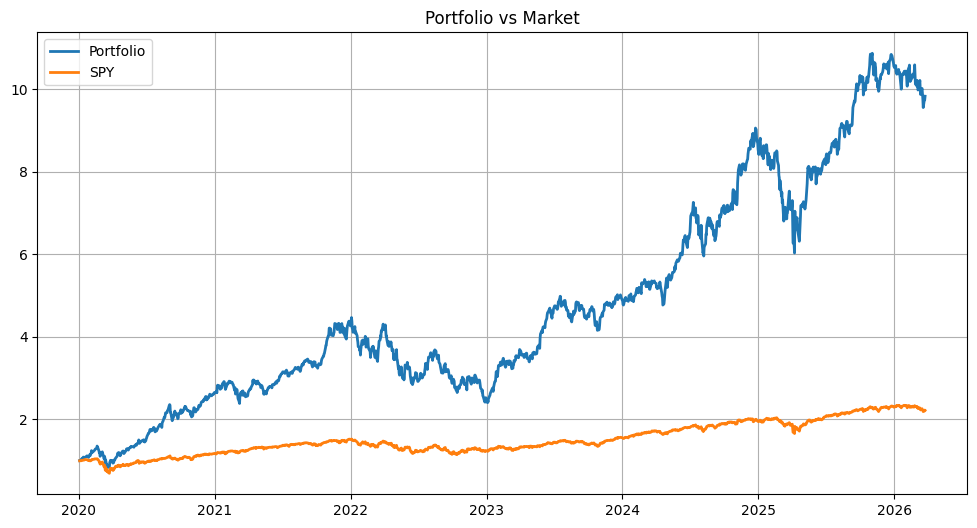

PORTFOLIO METRICS


,Total Return,Sharpe Ratio,Max Drawdown
Portfolio,8.824534,1.226158,-0.461114
SPY,1.212348,0.726899,-0.337173


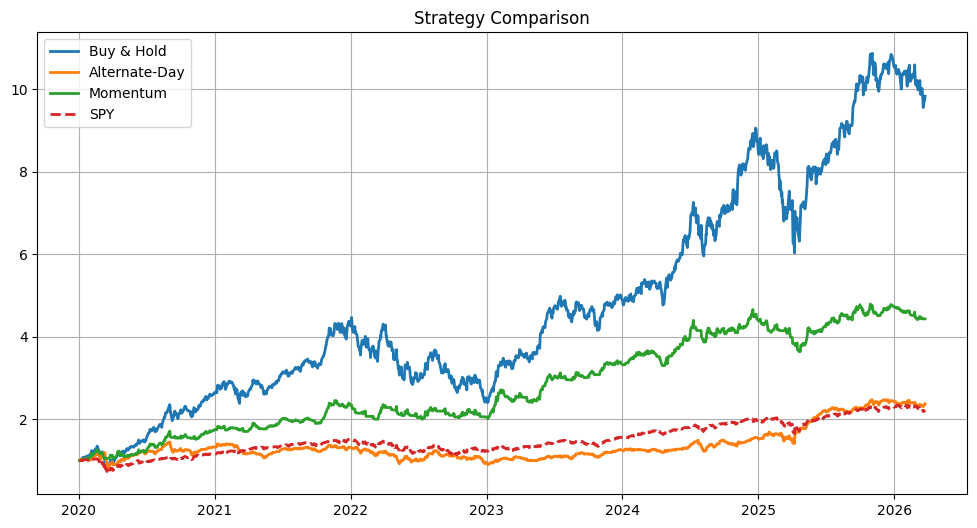

STRATEGY METRICS


,Total Return,Sharpe Ratio,Max Drawdown
Buy & Hold,8.824534,1.226158,-0.461114
Alternate-Day,1.372166,0.663451,-0.378295
Momentum,3.430835,1.274319,-0.218910
SPY,1.212348,0.726899,-0.337173


PREDICTION ACCURACY: 56.46 %


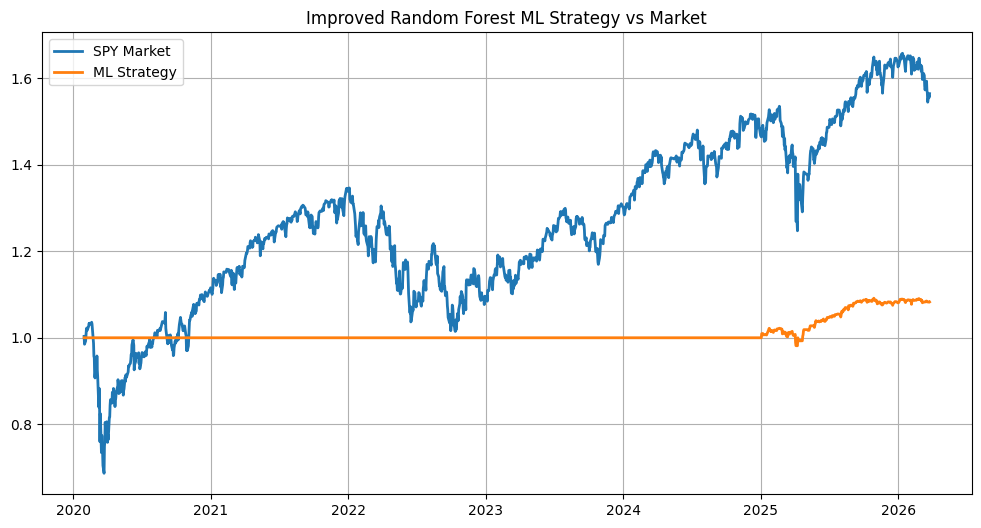

ML STRATEGY METRICS


,Total Return,Sharpe Ratio,Max Drawdown
ML Strategy,0.082795,0.604864,-0.039643


FEATURE IMPORTANCE


,Feature,Importance
2,Lag3,0.097398
0,Lag1,0.092388
8,MA10_Ratio,0.088654
9,MA20_Ratio,0.087113
4,Lag5,0.084765
1,Lag2,0.084258
5,Mom5,0.082420
11,RSI5,0.081011
10,Vol5,0.079330
3,Lag4,0.077454


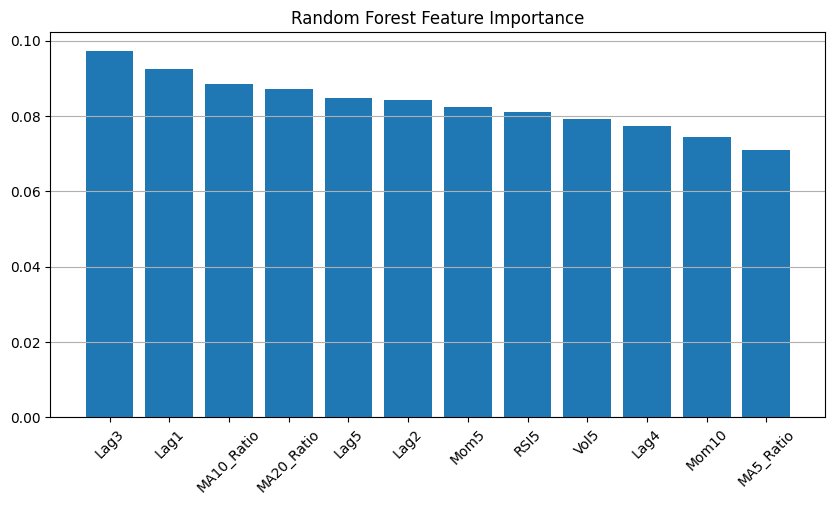

In [30]:
!pip install yfinance scikit-learn -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# =========================
# 1. DOWNLOAD DATA
# =========================
tickers = ["AAPL", "TSLA", "NVDA", "SPY"]
prices = yf.download(tickers, start="2020-01-01", auto_adjust=True)["Close"].dropna()

print("PRICE DATA")
display(prices.head())

# =========================
# 2. DAILY RETURNS
# =========================
returns = prices.pct_change().dropna()

print("RETURNS DATA")
display(returns.head())

# =========================
# 3. EQUAL-WEIGHT PORTFOLIO
# =========================
equal_weight_returns = returns.mean(axis=1)
equal_weight_curve = (1 + equal_weight_returns).cumprod()

market_curve = (1 + returns["SPY"]).cumprod()

# =========================
# 4. METRIC FUNCTIONS
# =========================
def sharpe_ratio(r):
    r = r.dropna()
    if r.std() == 0:
        return np.nan
    return np.sqrt(252) * r.mean() / r.std()

def max_drawdown(curve):
    running_max = curve.cummax()
    drawdown = curve / running_max - 1
    return drawdown.min()

def total_return(curve):
    return curve.iloc[-1] - 1

# =========================
# 5. PORTFOLIO VS MARKET GRAPH
# =========================
plt.figure(figsize=(12,6))
plt.plot(equal_weight_curve, label="Portfolio", linewidth=2)
plt.plot(market_curve, label="SPY", linewidth=2)
plt.legend()
plt.title("Portfolio vs Market")
plt.grid(True)
plt.show()

# =========================
# 6. PORTFOLIO METRICS TABLE
# =========================
portfolio_metrics = {
    "Total Return": total_return(equal_weight_curve),
    "Sharpe Ratio": sharpe_ratio(equal_weight_returns),
    "Max Drawdown": max_drawdown(equal_weight_curve)
}

market_metrics = {
    "Total Return": total_return(market_curve),
    "Sharpe Ratio": sharpe_ratio(returns["SPY"]),
    "Max Drawdown": max_drawdown(market_curve)
}

metrics_df = pd.DataFrame(
    [portfolio_metrics, market_metrics],
    index=["Portfolio", "SPY"]
)

print("PORTFOLIO METRICS")
display(metrics_df)

# =========================
# 7. STRATEGY COMPARISON
# =========================

# Buy & Hold
buy_hold_curve = equal_weight_curve.copy()

# Alternate-day strategy
signal_alt = pd.Series(0, index=returns.index)
signal_alt.iloc[::2] = 1
alt_returns = signal_alt.shift(1).fillna(0) * equal_weight_returns
alt_curve = (1 + alt_returns).cumprod()

# Momentum strategy
momentum_signal = (prices > prices.shift(5)).astype(int)
momentum_returns = (momentum_signal.shift(1).fillna(0) * returns).mean(axis=1)
momentum_curve = (1 + momentum_returns).cumprod()

plt.figure(figsize=(12,6))
plt.plot(buy_hold_curve, label="Buy & Hold", linewidth=2)
plt.plot(alt_curve, label="Alternate-Day", linewidth=2)
plt.plot(momentum_curve, label="Momentum", linewidth=2)
plt.plot(market_curve, label="SPY", linestyle="dashed", linewidth=2)
plt.legend()
plt.title("Strategy Comparison")
plt.grid(True)
plt.show()

strategy_metrics = pd.DataFrame({
    "Buy & Hold": {
        "Total Return": total_return(buy_hold_curve),
        "Sharpe Ratio": sharpe_ratio(equal_weight_returns),
        "Max Drawdown": max_drawdown(buy_hold_curve)
    },
    "Alternate-Day": {
        "Total Return": total_return(alt_curve),
        "Sharpe Ratio": sharpe_ratio(alt_returns),
        "Max Drawdown": max_drawdown(alt_curve)
    },
    "Momentum": {
        "Total Return": total_return(momentum_curve),
        "Sharpe Ratio": sharpe_ratio(momentum_returns),
        "Max Drawdown": max_drawdown(momentum_curve)
    },
    "SPY": {
        "Total Return": total_return(market_curve),
        "Sharpe Ratio": sharpe_ratio(returns["SPY"]),
        "Max Drawdown": max_drawdown(market_curve)
    }
}).T

print("STRATEGY METRICS")
display(strategy_metrics)

# =========================
# 8. MACHINE LEARNING DATASET
# =========================
spy = prices["SPY"].copy().to_frame()
spy["Returns"] = spy["SPY"].pct_change()

# Lag features
spy["Lag1"] = spy["Returns"].shift(1)
spy["Lag2"] = spy["Returns"].shift(2)
spy["Lag3"] = spy["Returns"].shift(3)
spy["Lag4"] = spy["Returns"].shift(4)
spy["Lag5"] = spy["Returns"].shift(5)

# Momentum features
spy["Mom5"] = spy["SPY"] / spy["SPY"].shift(5) - 1
spy["Mom10"] = spy["SPY"] / spy["SPY"].shift(10) - 1

# Moving average features
spy["MA5"] = spy["SPY"].rolling(5).mean()
spy["MA10"] = spy["SPY"].rolling(10).mean()
spy["MA20"] = spy["SPY"].rolling(20).mean()

spy["MA5_Ratio"] = spy["SPY"] / spy["MA5"]
spy["MA10_Ratio"] = spy["SPY"] / spy["MA10"]
spy["MA20_Ratio"] = spy["SPY"] / spy["MA20"]

# Volatility feature
spy["Vol5"] = spy["Returns"].rolling(5).std()

# RSI-style feature
gain = spy["Returns"].clip(lower=0).rolling(5).mean()
loss = (-spy["Returns"].clip(upper=0)).rolling(5).mean()
rs = gain / loss.replace(0, np.nan)
spy["RSI5"] = 100 - (100 / (1 + rs))

# Target: next day up/down
spy["Target"] = (spy["Returns"].shift(-1) > 0).astype(int)

spy = spy.dropna()

feature_cols = [
    "Lag1", "Lag2", "Lag3", "Lag4", "Lag5",
    "Mom5", "Mom10",
    "MA5_Ratio", "MA10_Ratio", "MA20_Ratio",
    "Vol5", "RSI5"
]

X = spy[feature_cols]
y = spy["Target"]

split = int(len(spy) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

# =========================
# 9. RANDOM FOREST MODEL
# =========================
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, pred)
print("PREDICTION ACCURACY:", round(acc * 100, 2), "%")

# =========================
# 10. ML STRATEGY
# =========================
spy["Prob"] = np.nan
spy.loc[X_test.index, "Prob"] = probs

# Position sizing based on confidence
spy["PositionSize"] = 0.0
spy.loc[X_test.index, "PositionSize"] = (spy.loc[X_test.index, "Prob"] - 0.5) * 4
spy["PositionSize"] = spy["PositionSize"].clip(lower=0, upper=1)

spy["ML_Returns"] = spy["PositionSize"].shift(1).fillna(0) * spy["Returns"]

spy["Market"] = (1 + spy["Returns"]).cumprod()
spy["ML_Curve"] = (1 + spy["ML_Returns"]).cumprod()

plt.figure(figsize=(12,6))
plt.plot(spy["Market"], label="SPY Market", linewidth=2)
plt.plot(spy["ML_Curve"], label="ML Strategy", linewidth=2)
plt.legend()
plt.title("Improved Random Forest ML Strategy vs Market")
plt.grid(True)
plt.show()

ml_metrics = {
    "Total Return": total_return(spy["ML_Curve"]),
    "Sharpe Ratio": sharpe_ratio(spy["ML_Returns"]),
    "Max Drawdown": max_drawdown(spy["ML_Curve"])
}

ml_metrics_df = pd.DataFrame([ml_metrics], index=["ML Strategy"])

print("ML STRATEGY METRICS")
display(ml_metrics_df)

# =========================
# 11. FEATURE IMPORTANCE
# =========================
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print("FEATURE IMPORTANCE")
display(importance_df)

plt.figure(figsize=(10,5))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.xticks(rotation=45)
plt.title("Random Forest Feature Importance")
plt.grid(True, axis="y")
plt.show()